In [1]:
# Imports
from scipy.io import loadmat
import pandas as pd
import numpy as np
import plotly.express as px
import torch.nn as nn
import torch
import itertools
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.linear_model import LinearRegression

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

cuda
True
NVIDIA GeForce RTX 4070 Ti SUPER


In [3]:
data = loadmat('Xtrain.mat')

In [4]:
def data_cleaning(df: pd.DataFrame) -> pd.DataFrame:
    normalized = df/255
    return normalized
    
def slices(s: pd.Series, slice_length) -> tuple[pd.Series, pd.Series]:
    slices = [window for window in s.rolling(window=slice_length+1)]
    res = [(slc.iloc[:-1], slc.iloc[-1]) for slc in slices[slice_length:]]
    return res

def cv_split(X: np.ndarray, Y: np.ndarray, n_splits=5, gap=0, overlap=False) -> list[tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, int, int]]:
    split_size = len(X) // n_splits
    splits = []
    for i in range(n_splits):
        start = i * split_size
        end = (i + 1) * split_size if i < n_splits - 1 else len(X)

        train_left_end = max(0, start - gap)
        train_right_start = min(len(X), end + gap)

        X_train = np.concatenate((X[:train_left_end], X[train_right_start:]), axis=0)
        Y_train = np.concatenate((Y[:train_left_end], Y[train_right_start:]), axis=0)
        X_val = X[start:end]
        Y_val = Y[start:end]
        splits.append((X_train, Y_train, X_val, Y_val, start, end))
        if i < n_splits - 1 and overlap:
            intermediate_start = (end - start) // 2 + start
            intermediate_end = intermediate_start + split_size

            train_left_end = max(0, intermediate_start - gap)
            train_right_start = min(len(X), intermediate_end + gap)

            X_train = np.concatenate((X[:train_left_end], X[train_right_start:]), axis=0)
            Y_train = np.concatenate((Y[:train_left_end], Y[train_right_start:]), axis=0)
            X_val = X[intermediate_start:intermediate_end]
            Y_val = Y[intermediate_start:intermediate_end]
            splits.append((X_train, Y_train, X_val, Y_val, intermediate_start, intermediate_end))
    return splits

In [5]:
class BaselineNN(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, output_size=1):
        super().__init__()

        self.flatten = nn.Flatten()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, output_size),
            nn.Sigmoid() # since we normalized the data to [0,1]
        )

    def forward(self, x):
        x = self.flatten(x)
        out = self.linear_relu_stack(x)

        return out

In [6]:
class LSTMModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2):
        super().__init__()
        
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True # needed because we have (batch_size, seq_len, 1). So batch size is given first
        )
        
        self.fc = nn.Linear(hidden_size, 1) # Connects final layer to output

    def forward(self, x):
        # x shape: (batch_size, seq_len, input_size)

        # pass through model
        out, _ = self.lstm(x)

        # out contains hidden states for all timesteps:
        # shape: (batch_size, seq_len, hidden_size)
        
        # we only care about last timestep.
        out = out[:, -1, :] #takes last timestep
        out = self.fc(out) # gets prediction
        
        return out

In [7]:
class GRUModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2):
        super().__init__()
        
        self.lstm = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True # needed because we have (batch_size, seq_len, 1). So batch size is given first
        )
        
        self.fc = nn.Linear(hidden_size, 1) # Connects final layer to output

    def forward(self, x):
        # x shape: (batch_size, seq_len, input_size)

        # pass through model
        out, _ = self.lstm(x)

        # out contains hidden states for all timesteps:
        # shape: (batch_size, seq_len, hidden_size)
        
        # we only care about last timestep.
        out = out[:, -1, :] #takes last timestep
        out = self.fc(out) # gets prediction
        
        return out

In [14]:
class LinearRegressionModel:
    def __init__(self, **kwargs):
        self.model = LinearRegression()

    # should do nothing. Ensures compatibilityy with neural network code
    def to(self, device):
        return self

    # should do nothing. Ensures compatibilityy with neural network code
    def train(self):
        pass

    # should do nothing. Ensures compatibilityy with neural network code
    def eval(self):
        pass

    def fit(self, X, y):
        # flatten
        if len(X.shape) == 3:
            X = X.reshape(X.shape[0], -1) # remove last part

        self.model.fit(X, y.ravel())

    # this function run when model is called via model(). we make this the predict function, since our code does model(X) to get predictions from neural networks, but Linear regression needs model.predict(X) so we bind model(X) to this function
    def __call__(self, X):
        if isinstance(X, torch.Tensor):
            X = X.cpu().numpy()

        if len(X.shape) == 3:
            X = X.reshape(X.shape[0], -1)

        return torch.tensor(self.model.predict(X).reshape(-1, 1),dtype=torch.float32) # return predict function

In [9]:
def train_model(X_train, Y_train, X_val, Y_val, seed, device, learning_rate, epochs, model_class, model_kwargs, noise):
    torch.manual_seed(seed)
    np.random.seed(seed)

    model = model_class(**model_kwargs).to(device)

    # if linear regression model only run fit
    if isinstance(model, LinearRegressionModel):
        model.fit(X_train.cpu().numpy(), Y_train.cpu().numpy()) # run fit
        return model # skip everything else

    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='min',
        factor=0.5,
        patience=10,
        min_lr=1e-5
    )

    current_lr = optimizer.param_groups[0]['lr']

    for epoch in range(epochs):
        model.train()
        #train_loss_epoch = 0.0

        optimizer.zero_grad()
        noise = torch.randn_like(X_train) * noise # add noise, model learns to predict with imperfect inputs
        pred = model(X_train + noise)
        #pred = model(X_train)
        loss = criterion(pred, Y_train)
        loss.backward()
        optimizer.step()

        #train_loss_epoch += loss.item()

        #train_loss_epoch /= len(loader)

        # validation loss for scheduler
        model.eval()
        with torch.no_grad():
            val_pred = model(X_val)
            val_loss = criterion(val_pred, Y_val).item()

        scheduler.step(val_loss)
        new_lr = optimizer.param_groups[0]['lr']

        #if new_lr != current_lr:
            #print(f"Learning rate reduced: {current_lr:.6f} -> {new_lr:.6f} in epoch {epoch}")

        current_lr = new_lr

    return model

In [10]:
def ensemble_recursive_predict(models, start_tensor, steps, device):
    window = start_tensor.clone().unsqueeze(0)
    preds = []

    for _ in range(steps):
        step_preds = []

        for model in models:
            with torch.no_grad():
                pred = model(window)
                step_preds.append(pred.item())

        avg_pred = np.mean(step_preds)
        preds.append(avg_pred)

        new_point = torch.tensor([[[avg_pred]]], dtype=torch.float32).to(device)
        window = torch.cat([window[:, 1:, :], new_point], dim=1)

    return np.array(preds)

# Grid search

Set model_class to change type of model

In [18]:
# hyperparameters to try
window_sizes = [32, 64]
hidden_sizes = [32, 64]
num_layers_list = [1, 2]
epochs_list = [12500]
learning_rates = [1e-2]
noise = [0, 0.1]

seed=1000
model_class = LSTMModel # Type of model

all_results = []

# create data
series_full = pd.Series(data['Xtrain'].flatten())
series_full = data_cleaning(series_full).values

for window_size, hidden_size, num_layers, epochs, learning_rate, noise in itertools.product(window_sizes, hidden_sizes, num_layers_list, epochs_list, learning_rates, noise):

    #set model kwargs based on chosen model
    if model_class == BaselineNN:

        model_kwargs = {
            "input_size": window_size,
            "hidden_size": hidden_size,
        }
    elif model_class in [LSTMModel, GRUModel]:

        model_kwargs = {
            "hidden_size": hidden_size,
            "num_layers": num_layers
        }
    elif model_class == LinearRegressionModel:
        model_kwargs= {}

    print(f"\nRunning: window={window_size}, hidden={hidden_size}, layers={num_layers}, epochs={epochs}, learning rate={learning_rate}, noise={noise}")

    # recreate dataset with current chosen window
    df = pd.Series(data['Xtrain'].flatten())
    df = data_cleaning(df)

    X, Y = zip(*slices(df, window_size))

    X = np.array(X).reshape(-1, window_size, 1)
    Y = np.array(Y).reshape(-1, 1)

    # use cross validation
    fold_results = []
    for fold_idx, (X_train, Y_train, X_val, Y_val, val_start, val_end) in enumerate(cv_split(X, Y, n_splits=4, gap=window_size, overlap=True), start=1):
        #print(f"\nFold {fold_idx}: Validate on [{val_start}:{val_end}]")
        # Convert to PyTorch tensors
        X_train = torch.tensor(X_train, dtype=torch.float32)
        Y_train = torch.tensor(Y_train, dtype=torch.float32)
        X_val = torch.tensor(X_val, dtype=torch.float32)
        Y_val = torch.tensor(Y_val, dtype=torch.float32)

        # switch to gpu
        X_train = X_train.to(device)
        Y_train = Y_train.to(device)
        X_val = X_val.to(device)
        Y_val = Y_val.to(device)

        # create model
        n_models = 1
        models = []

        for i in range(n_models):
            #print(f"  Training model {i+1}/{n_models}")

            model_i = train_model(
                X_train, Y_train,
                X_val, Y_val,
                seed=seed + i, # different seed per model
                device=device,
                learning_rate=learning_rate,
                epochs=epochs,
                model_class=model_class,
                model_kwargs=model_kwargs,
                noise=noise
            )

            models.append(model_i)

        #-------------------------------------------------
        # 1-step evaluation
        #-------------------------------------------------
        with torch.no_grad():
            preds = []
            for model in models:
                preds.append(model(X_val).cpu().numpy())

        val_pred = np.mean(preds, axis=0)
        y_true = Y_val.cpu().numpy()

        mae_1 = mean_absolute_error(y_true, val_pred)
        mse_1 = mean_squared_error(y_true, val_pred)
        #-------------------------------------------------

        #-------------------------------------------------
        # 200-step evaluation
        #-------------------------------------------------
        start_idx = val_start
        start_window = series_full[start_idx:start_idx + window_size]

        # determine max possible steps
        max_steps = len(series_full) - (start_idx + window_size)
        steps = min(200, max_steps)

        true_future = series_full[start_idx + window_size:start_idx + window_size + steps]  # true values

        # convert start window to tensor
        start_tensor = torch.tensor(start_window.reshape(window_size, 1), dtype=torch.float32).to(device)

        preds = ensemble_recursive_predict(models, start_tensor, steps, device) # predictions

        mae_200 = mean_absolute_error(true_future, preds)
        mse_200 = mean_squared_error(true_future, preds)
        #-------------------------------------------------

        fold_results.append({
            "fold": fold_idx,
            "mae_1": mae_1,
            "mse_1": mse_1,
            "mae_200": mae_200,
            "mse_200": mse_200,
        })

    mae_1_mean = np.mean([item["mae_1"] for item in fold_results])
    mae_1_std = np.std([item["mae_1"] for item in fold_results])

    mse_1_mean = np.mean([item["mse_1"] for item in fold_results])
    mse_1_std = np.std([item["mse_1"] for item in fold_results])

    mae_200_mean = np.mean([item["mae_200"] for item in fold_results])
    mae_200_std = np.std([item["mae_200"] for item in fold_results])

    mse_200_mean = np.mean([item["mse_200"] for item in fold_results])
    mse_200_std = np.std([item["mse_200"] for item in fold_results])

    all_results.append({
        "window": window_size,
        "hidden": hidden_size,
        "layers": num_layers,
        "epochs": epochs,
        "lr": learning_rate,
        "noise": noise,
        "mae_1_mean": mae_1_mean,
        "mae_200_mean": mae_200_mean,
        "mae_200_std": mae_200_std,
        "mse_1_mean": mse_1_mean,
        "mse_200_mean": mse_200_mean,
        "mse_200_std": mse_200_std,
    })

    print(f"\nRESULT:")
    print(f"1-step MAE: {mae_1_mean:.4f} +- {mae_1_std:.4f}")
    print(f"200-step MAE: {mae_200_mean:.4f} +- {mae_200_std:.4f}")


sorted_results = sorted(all_results, key=lambda x: x["mae_200_mean"])

print("\nTOP MODELS:")
for r in sorted_results[:5]:
    print(r)


Running: window=32, hidden=32, layers=1, epochs=12500, learning rate=0.01, noise=0

RESULT:
1-step MAE: 0.0112 +- 0.0065
200-step MAE: 0.1170 +- 0.0637

Running: window=32, hidden=32, layers=1, epochs=12500, learning rate=0.01, noise=0.1


KeyboardInterrupt: 

# ------------------------
# Try best model, check pattern changes in plots


Fold 1: Validate on [0:242]
  Training model 1/1

1-step MAE: 0.0101 +- 0.0000

1-step MSE: 0.0009 +- 0.0000

200-step MAE: 0.0816 +- 0.0000

200-step MSE: 0.0205 +- 0.0000


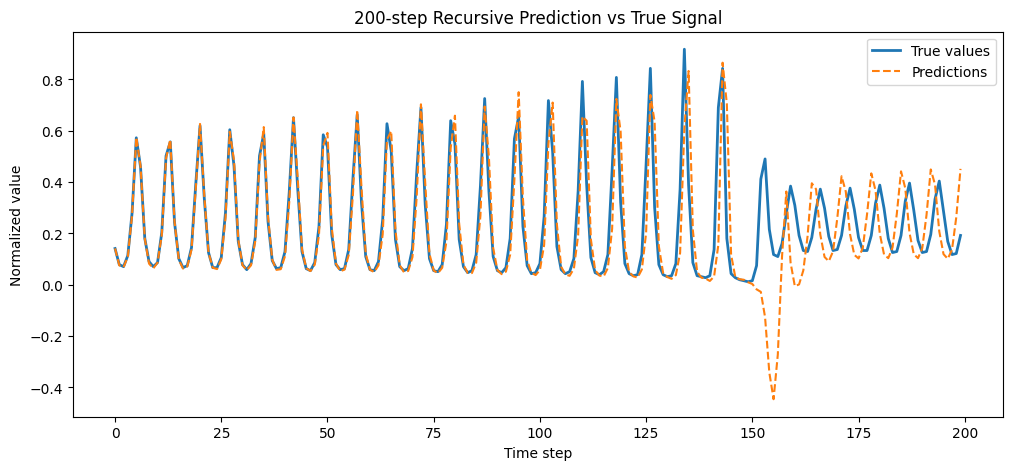


Fold 2: Validate on [121:363]
  Training model 1/1

1-step MAE: 0.0100 +- 0.0002

1-step MSE: 0.0012 +- 0.0002

200-step MAE: 0.0794 +- 0.0023

200-step MSE: 0.0179 +- 0.0026


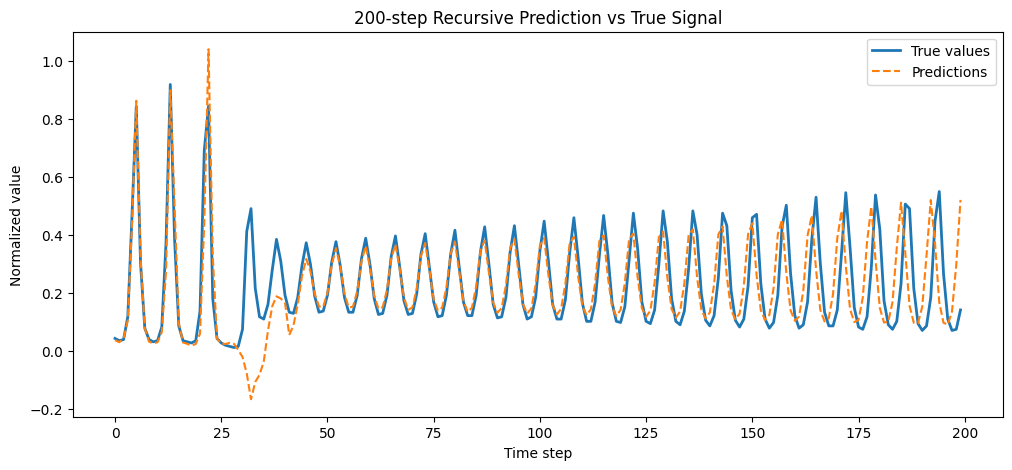


Fold 3: Validate on [242:484]
  Training model 1/1

1-step MAE: 0.0092 +- 0.0012

1-step MSE: 0.0010 +- 0.0003

200-step MAE: 0.0737 +- 0.0082

200-step MSE: 0.0154 +- 0.0041


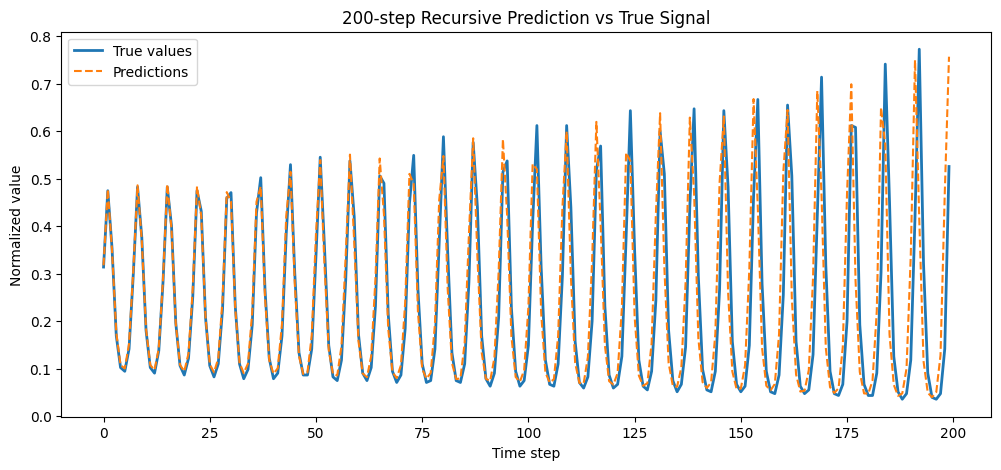


Fold 4: Validate on [363:605]
  Training model 1/1

1-step MAE: 0.0151 +- 0.0104

1-step MSE: 0.0031 +- 0.0035

200-step MAE: 0.0905 +- 0.0301

200-step MSE: 0.0261 +- 0.0189


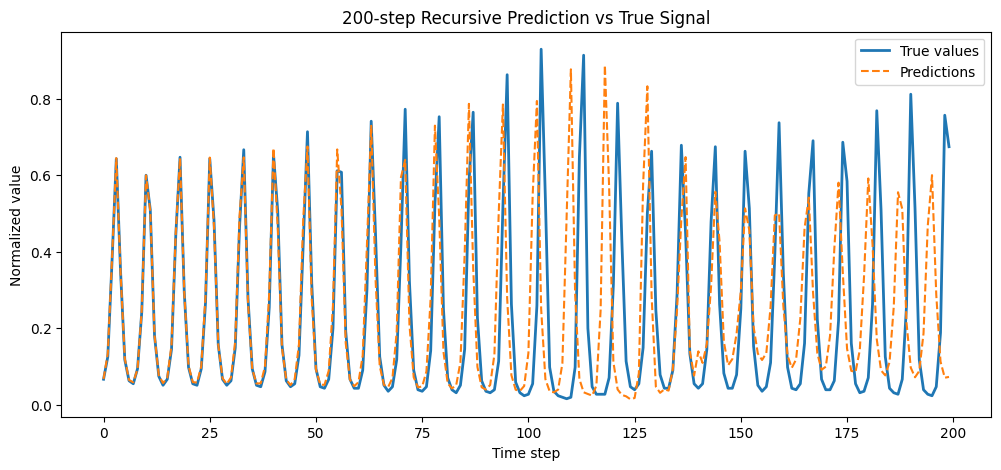


Fold 5: Validate on [484:726]
  Training model 1/1

1-step MAE: 0.0174 +- 0.0103

1-step MSE: 0.0038 +- 0.0035

200-step MAE: 0.1079 +- 0.0438

200-step MSE: 0.0302 +- 0.0188


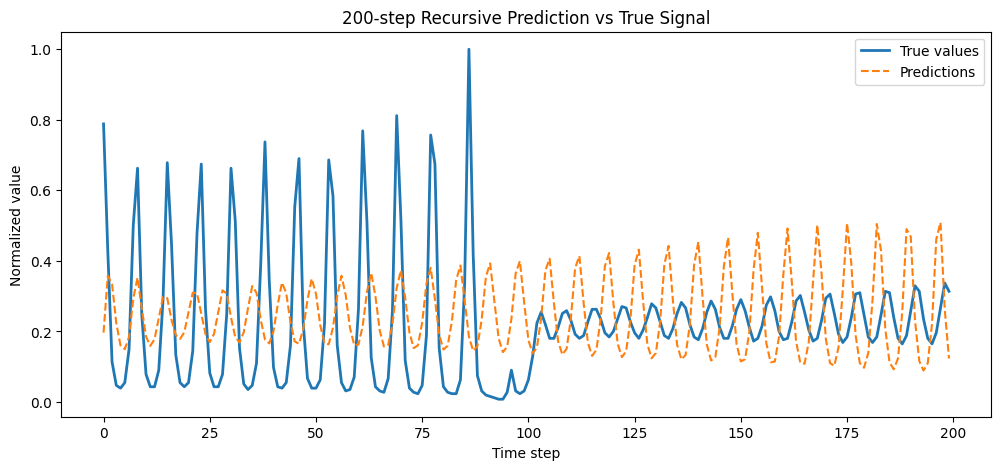


Fold 6: Validate on [605:847]
  Training model 1/1

1-step MAE: 0.0156 +- 0.0102

1-step MSE: 0.0032 +- 0.0035

200-step MAE: 0.0914 +- 0.0544

200-step MSE: 0.0252 +- 0.0205


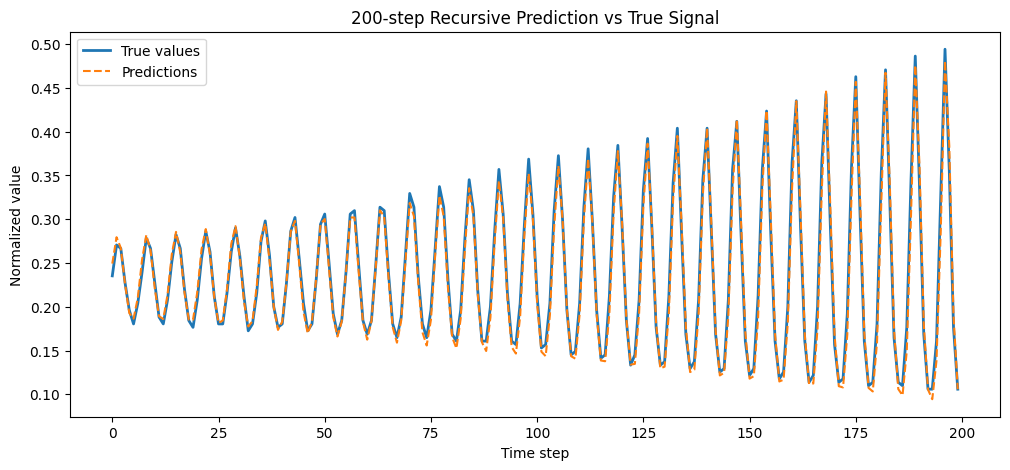


Fold 7: Validate on [726:968]
  Training model 1/1

1-step MAE: 0.0139 +- 0.0104

1-step MSE: 0.0027 +- 0.0034

200-step MAE: 0.0802 +- 0.0574

200-step MSE: 0.0217 +- 0.0209


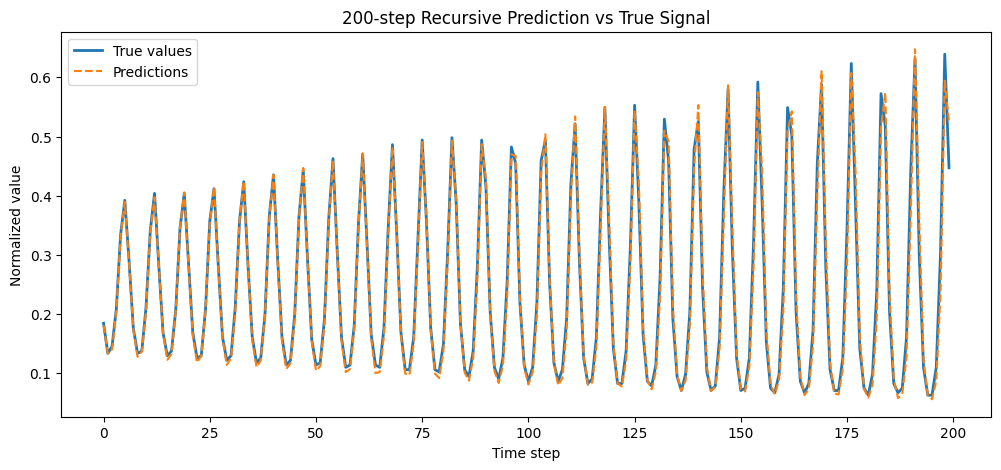

In [16]:
seed=1000

# Hyperparameters
window_size = 32
hidden_size = 32
num_layers = 2
epochs = 12500
learning_rate = 1e-2
noise = 0.1
model_class = LSTMModel # Type of model


#set model kwargs based on chosen model
if model_class == BaselineNN:

    model_kwargs = {
        "input_size": window_size,
        "hidden_size": hidden_size,
    }

elif model_class in [LSTMModel, GRUModel]:

    model_kwargs = {
        "hidden_size": hidden_size,
        "num_layers": num_layers
    }


# create data
series_full = pd.Series(data['Xtrain'].flatten())
series_full = data_cleaning(series_full).values

# recreate dataset with current chosen window
df = pd.Series(data['Xtrain'].flatten())
df = data_cleaning(df)

X, Y = zip(*slices(df, window_size))

X = np.array(X).reshape(-1, window_size, 1)
Y = np.array(Y).reshape(-1, 1)

# use cross validation
fold_results = []
for fold_idx, (X_train, Y_train, X_val, Y_val, val_start, val_end) in enumerate(cv_split(X, Y, n_splits=4, gap=window_size, overlap=True), start=1):
    print(f"\nFold {fold_idx}: Validate on [{val_start}:{val_end}]")
    # Convert to PyTorch tensors
    X_train = torch.tensor(X_train, dtype=torch.float32)
    Y_train = torch.tensor(Y_train, dtype=torch.float32)
    X_val = torch.tensor(X_val, dtype=torch.float32)
    Y_val = torch.tensor(Y_val, dtype=torch.float32)

    # switch to gpu
    X_train = X_train.to(device)
    Y_train = Y_train.to(device)
    X_val = X_val.to(device)
    Y_val = Y_val.to(device)

    # create model
    n_models = 1
    models = []

    for i in range(n_models):
        print(f"  Training model {i+1}/{n_models}")

        model_i = train_model(
            X_train, Y_train,
            X_val, Y_val,
            seed=seed + i, # different seed per model
            device=device,
            learning_rate=learning_rate,
            epochs=epochs,
            model_class=model_class,
            model_kwargs=model_kwargs,
            noise=noise
        )

        models.append(model_i)

    #-------------------------------------------------
    # 1-step evaluation
    #-------------------------------------------------
    with torch.no_grad():
        preds = []
        for model in models:
            preds.append(model(X_val).cpu().numpy())

    val_pred = np.mean(preds, axis=0)
    y_true = Y_val.cpu().numpy()

    mae_1 = mean_absolute_error(y_true, val_pred)
    mse_1 = mean_squared_error(y_true, val_pred)
    #-------------------------------------------------

    #-------------------------------------------------
    # 200-step evaluation
    #-------------------------------------------------
    start_idx = val_start
    start_window = series_full[start_idx:start_idx + window_size]

    # determine max possible steps
    max_steps = len(series_full) - (start_idx + window_size)
    steps = min(200, max_steps)

    true_future = series_full[start_idx + window_size:start_idx + window_size + steps]  # true values

    # convert start window to tensor
    start_tensor = torch.tensor(start_window.reshape(window_size, 1), dtype=torch.float32).to(device)

    preds = ensemble_recursive_predict(models, start_tensor, steps, device) # predictions

    mae_200 = mean_absolute_error(true_future, preds)
    mse_200 = mean_squared_error(true_future, preds)
    #-------------------------------------------------

    fold_results.append({
        "fold": fold_idx,
        "mae_1": mae_1,
        "mse_1": mse_1,
        "mae_200": mae_200,
        "mse_200": mse_200,
    })

    mae_1_values = [item["mae_1"] for item in fold_results]
    mse_1_values = [item["mse_1"] for item in fold_results]
    mae_200_values = [item["mae_200"] for item in fold_results]
    mse_200_values = [item["mse_200"] for item in fold_results]

    print(f"\n1-step MAE: {np.mean(mae_1_values):.4f} +- {np.std(mae_1_values):.4f}")
    print(f"\n1-step MSE: {np.mean(mse_1_values):.4f} +- {np.std(mse_1_values):.4f}")
    print(f"\n200-step MAE: {np.mean(mae_200_values):.4f} +- {np.std(mae_200_values):.4f}")
    print(f"\n200-step MSE: {np.mean(mse_200_values):.4f} +- {np.std(mse_200_values):.4f}")

    #-----------------------
    # plot
    #-----------------------
    import matplotlib.pyplot as plt

    # Create x-axis (time steps)
    t = range(len(true_future))

    plt.figure(figsize=(12, 5))

    # True signal
    plt.plot(t, true_future, label="True values", linewidth=2)

    # Predicted signal
    plt.plot(t, preds, label="Predictions", linestyle='--')

    plt.title("200-step Recursive Prediction vs True Signal")
    plt.xlabel("Time step")
    plt.ylabel("Normalized value")
    plt.legend()

    plt.show()
